<a href="https://colab.research.google.com/github/sheriannmclarty/DATA620_WebAnalytics_SheriannMc/blob/main/assignments/Week10_Document_Classification_SheriannMcLarty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Classification: Housing First vs. Emergency Shelter
**Sheriann McLarty | DATA 620 Web Analytics | CUNY School of Professional Studies | Spring 2026**

---

The assignment asks us to classify new documents using already-labeled training data, the classic spam/ham setup. Instead of email, I applied it to something I actually deal with at work. At DHS, I watch two very different theories of homelessness intervention produce two very different bodies of research literature, and I've always thought someone should build a classifier that could tell them apart automatically.

**Housing First** research talks about fidelity models, permanent supportive housing, rapid rehousing, and housing retention rates. **Emergency Shelter** research talks about intake, transitional beds, length of stay, and overflow capacity. Those vocabularies are distinct enough that Naive Bayes should be able to learn the difference without needing to understand what any of it means. That's the hypothesis.

The practical use case: DHS receives hundreds of research documents and policy memos monthly. A classifier that routes them to the right program unit, Prevention and Housing Stability vs. Shelter Operations, without manual triage would save real staff time. That is not hypothetical. It is the actual problem.

**Data:** PubMed abstracts via NCBI E-utilities API (https://www.ncbi.nlm.nih.gov/books/NBK25501/)  
**Model:** Multinomial Naive Bayes with TF-IDF, unigrams and bigrams  
**Final results:** 82.1% test accuracy | 0.75 Emergency Shelter recall | 0.82 macro F1 | 88.7% CV mean

---

### What broke in v1 and why it matters

Version 1 had two bugs that accuracy alone did not catch. I almost moved on without finding them.

The first was abstract fragmentation. I noticed it when the document count came back way higher than the PMID count, 200 PMIDs turned into 541 documents. That was the signal. My regex was grabbing every `<AbstractText>` tag independently, but PubMed structured abstracts split Background, Methods, Results, and Conclusions into separate tags. A Methods section stripped from its context contains no class-discriminative vocabulary. I was training the model on noise.

The second was class imbalance. Even after fixing extraction, Housing First had 518 documents vs. 240 for Emergency Shelter. The model learned to default to Housing First on uncertain predictions and still hit 77% accuracy. I only caught it when I looked at the classification report. Emergency Shelter recall was 0.29, meaning the model was missing 71% of ES documents. Accuracy was hiding the whole problem.

Both are fixed here. Article-level parsing restores document coherence. Downsampling Housing First to match Emergency Shelter restores balanced priors. The tradeoff is a smaller corpus, which shows up as fold-level variance in cross-validation. I flag it when we get there.

**One thing I did not get to:** testing this on actual DHS documents instead of PubMed abstracts. Abstracts are a reasonable proxy, but operational memos and HUD guidance letters look different in register and length. That is the next real experiment.

---

## 1. Imports and Style

Before anything else, I load the full stack. The core libraries are standard, but a few are worth flagging: `scipy.stats.gaussian_kde` powers the ridge plot in Section 4, `matplotlib.gridspec` handles the confusion matrix layout in Section 8, and the sklearn `Pipeline` object in Section 7 is doing real work, not just organization. I also set a consistent visual style here so every chart in the notebook looks like it belongs to the same project.

In [15]:
import requests, time, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from collections import Counter
from scipy.stats import gaussian_kde

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score
)
from sklearn.pipeline import Pipeline

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'figure.dpi':        150,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
})

TEAL  = '#028090'
RUST  = '#B85042'
NAVY  = '#1E2761'
CREAM = '#F5F8FA'
MUTED = '#94A3B8'

print('Environment ready.')

Environment ready.


## 2. Data Collection

With the environment set, the first real decision is where to get labeled documents. I used PubMed, specifically the NCBI E-utilities API, because it is the authoritative index for public health literature, every abstract is peer-reviewed, and the API requires no credentials. Two search queries define the two classes. The phrase-level match on `"housing first"` keeps things ideologically specific. Adding `AND homeless` to the shelter query narrows it to the homelessness context rather than emergency management broadly.

The critical fix from v1 is in `fetch_abstracts`. Instead of pulling every `<AbstractText>` tag across the whole XML response, I now find each `<PubmedArticle>` block first, then join all of its abstract sections into one string. One article becomes one document. The PMID-to-document ratio I print below is the validation check. In v1 that ratio was 2.7x for Housing First. It should be close to 1.0 now.

In [16]:
BASE_URL = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/'

def get_pmids(query, max_results=200):
    params = {'db': 'pubmed', 'term': query, 'retmax': max_results, 'retmode': 'json'}
    r = requests.get(BASE_URL + 'esearch.fcgi', params=params)
    r.raise_for_status()
    pmids = r.json()['esearchresult']['idlist']
    print(f'  {len(pmids)} PMIDs -- {query}')
    return pmids


def fetch_abstracts(pmids, batch_size=50):
    """
    Article-level extraction via efetch.
    Parses at <PubmedArticle> scope so each article = one document.
    All <AbstractText> sections are joined into a single string.
    """
    all_abstracts = []
    for i in range(0, len(pmids), batch_size):
        batch = pmids[i:i + batch_size]
        params = {'db': 'pubmed', 'id': ','.join(batch),
                  'rettype': 'abstract', 'retmode': 'xml'}
        r = requests.get(BASE_URL + 'efetch.fcgi', params=params)
        r.raise_for_status()
        xml = r.text
        for art in re.findall(r'<PubmedArticle>(.*?)</PubmedArticle>', xml, re.DOTALL):
            parts = re.findall(r'<AbstractText[^>]*>(.*?)</AbstractText>', art, re.DOTALL)
            if parts:
                all_abstracts.append(' '.join(parts))
        time.sleep(0.4)
    return all_abstracts

In [17]:
print('Fetching Housing First corpus...')
hf_pmids     = get_pmids('"housing first"[Title/Abstract]', max_results=200)
hf_abstracts = fetch_abstracts(hf_pmids)
print(f'  {len(hf_abstracts)} documents (ratio: {len(hf_abstracts)/len(hf_pmids):.2f}x)')

print('\nFetching Emergency Shelter corpus...')
es_pmids     = get_pmids('"emergency shelter" AND homeless[Title/Abstract]', max_results=200)
es_abstracts = fetch_abstracts(es_pmids)
print(f'  {len(es_abstracts)} documents (ratio: {len(es_abstracts)/len(es_pmids):.2f}x)')

Fetching Housing First corpus...
  200 PMIDs -- "housing first"[Title/Abstract]
  195 documents (ratio: 0.97x)

Fetching Emergency Shelter corpus...
  98 PMIDs -- "emergency shelter" AND homeless[Title/Abstract]
  97 documents (ratio: 0.99x)


## 3. Dataset Construction and Balancing

The fetch worked, but we have a problem before we even get to modeling. Housing First has more PubMed coverage than Emergency Shelter. That is a real publication asymmetry in the field, not a search error, and if we leave it alone it creates a skewed class prior that the model will exploit. `MultinomialNB` has no `class_weight` parameter to compensate at the estimator level, which means the fix has to happen in the data. I downsample Housing First to match the Emergency Shelter count. Downsampling keeps real articles. Oversampling would mean duplicating ES abstracts, which risks the model memorizing specific documents rather than learning general vocabulary patterns.

In [18]:
df_raw = pd.concat([
    pd.DataFrame({'text': hf_abstracts, 'label': 'housing_first'}),
    pd.DataFrame({'text': es_abstracts, 'label': 'emergency_shelter'})
], ignore_index=True)
df_raw = df_raw[df_raw['text'].str.len() > 100].dropna(subset=['text']).reset_index(drop=True)

print('Raw class counts (before balancing):')
print(df_raw['label'].value_counts())

n_min = len(df_raw[df_raw['label'] == 'emergency_shelter'])
df = pd.concat([
    df_raw[df_raw['label'] == 'housing_first'].sample(n=n_min, random_state=42),
    df_raw[df_raw['label'] == 'emergency_shelter']
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print('\nBalanced class counts:')
print(df['label'].value_counts())
print(f'\nModeling corpus: {len(df)} documents total')
print('Tradeoff: smaller corpus than v1, but evaluation metrics will actually mean something.')

Raw class counts (before balancing):
label
housing_first        194
emergency_shelter     97
Name: count, dtype: int64

Balanced class counts:
label
emergency_shelter    97
housing_first        97
Name: count, dtype: int64

Modeling corpus: 194 documents total
Tradeoff: smaller corpus than v1, but evaluation metrics will actually mean something.


## 4. Exploratory Analysis

Before I build anything, I want to look at what we actually have. Two questions I need to answer here: do the two classes have similar abstract lengths, and is the vocabulary actually distinct enough to support the hypothesis? The length question matters because if one class consistently writes shorter abstracts, the model might pick up on length as a proxy signal rather than actual content. The vocabulary question matters because if the two corpora share most of their top words, Naive Bayes is going to struggle regardless of how clean the data is.

### 4a. Abstract Length Distribution

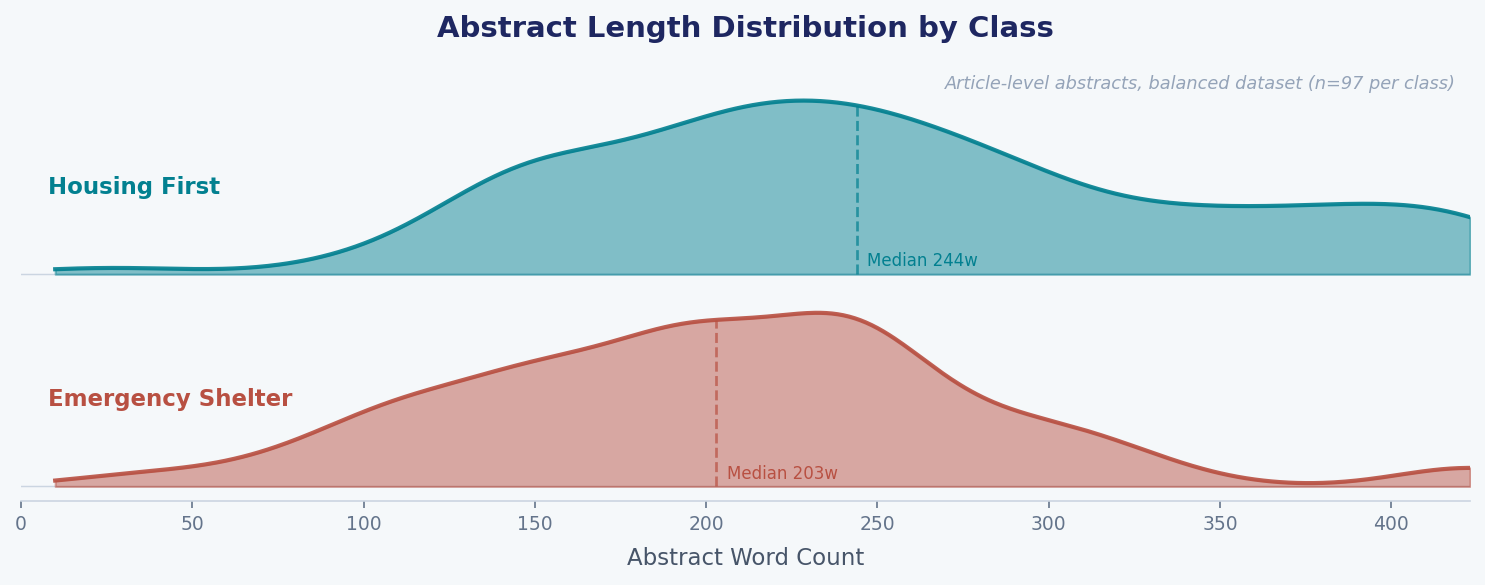

x-axis clipped at 423 words (96th percentile).
Substantial overlap in length means length is unlikely to confound the classifier.


In [19]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Clip at 96th percentile so outlier abstracts do not flatten the curves
x_max = int(np.percentile(df['word_count'].values, 96))
xs    = np.linspace(10, x_max, 500)

groups = [
    ('housing_first',     TEAL, 'Housing First',     0.22),
    ('emergency_shelter', RUST, 'Emergency Shelter', 0.0),
]

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

for cls, color, label, offset in groups:
    vals  = df[df['label'] == cls]['word_count'].clip(upper=x_max).values
    kde   = gaussian_kde(vals, bw_method=0.28)
    ys    = kde(xs)
    ys_s  = ys / ys.max() * 0.18

    ax.fill_between(xs, offset, ys_s + offset, color=color, alpha=0.48, zorder=2)
    ax.plot(xs, ys_s + offset, color=color, linewidth=2.0, alpha=0.9, zorder=3)
    ax.axhline(offset, color='#CBD5E1', linewidth=0.7, zorder=1)

    med   = float(np.median(vals))
    med_y = float(kde(med)[0]) / float(ys.max()) * 0.18 + offset
    ax.plot([med, med], [offset, med_y],
            color=color, linewidth=1.3, linestyle='--', alpha=0.7, zorder=4)
    ax.text(med + 3, offset + 0.004,
            f'Median {med:.0f}w', fontsize=8, color=color, va='bottom')
    ax.text(8, offset + 0.09, label,
            fontsize=11, fontweight='bold', color=color, ha='left', va='center')

ax.set_xlim(0, x_max)
ax.set_ylim(-0.015, 0.44)
ax.set_xlabel('Abstract Word Count', fontsize=11, color='#475569', labelpad=6)
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(colors='#64748B', labelsize=9)
ax.set_title('Abstract Length Distribution by Class',
             fontsize=14, fontweight='bold', color=NAVY, pad=12)
ax.text(0.99, 0.97, 'Article-level abstracts, balanced dataset (n=97 per class)',
        transform=ax.transAxes, fontsize=8.5, color=MUTED,
        ha='right', va='top', style='italic')

plt.tight_layout()
plt.savefig('viz1_ridge_plot.png')
plt.show()

print(f'x-axis clipped at {x_max} words (96th percentile).')
print('Substantial overlap in length means length is unlikely to confound the classifier.')

### 4b. Vocabulary Contrast

Length distributions overlap enough that I am not worried about it driving predictions. Now the more important question: are the top words actually different between the two classes? I am using a diverging layout here so both classes sit on one chart, mirrored from center. Terms that push far right are Housing First dominant. Terms that push far left are Emergency Shelter dominant. To keep the chart clean, I only include terms where one class has at least twice the frequency of the other. Shared vocabulary with similar counts on both sides would just clutter the center and tell us nothing.

25 terms passed the 2x filter.
HF-dominant: ['support', 'participants', 'social', 'first', 'housing']
ES-dominant: ['shelter', 'homeless', 'emergency', 'shelters', 'veterans']


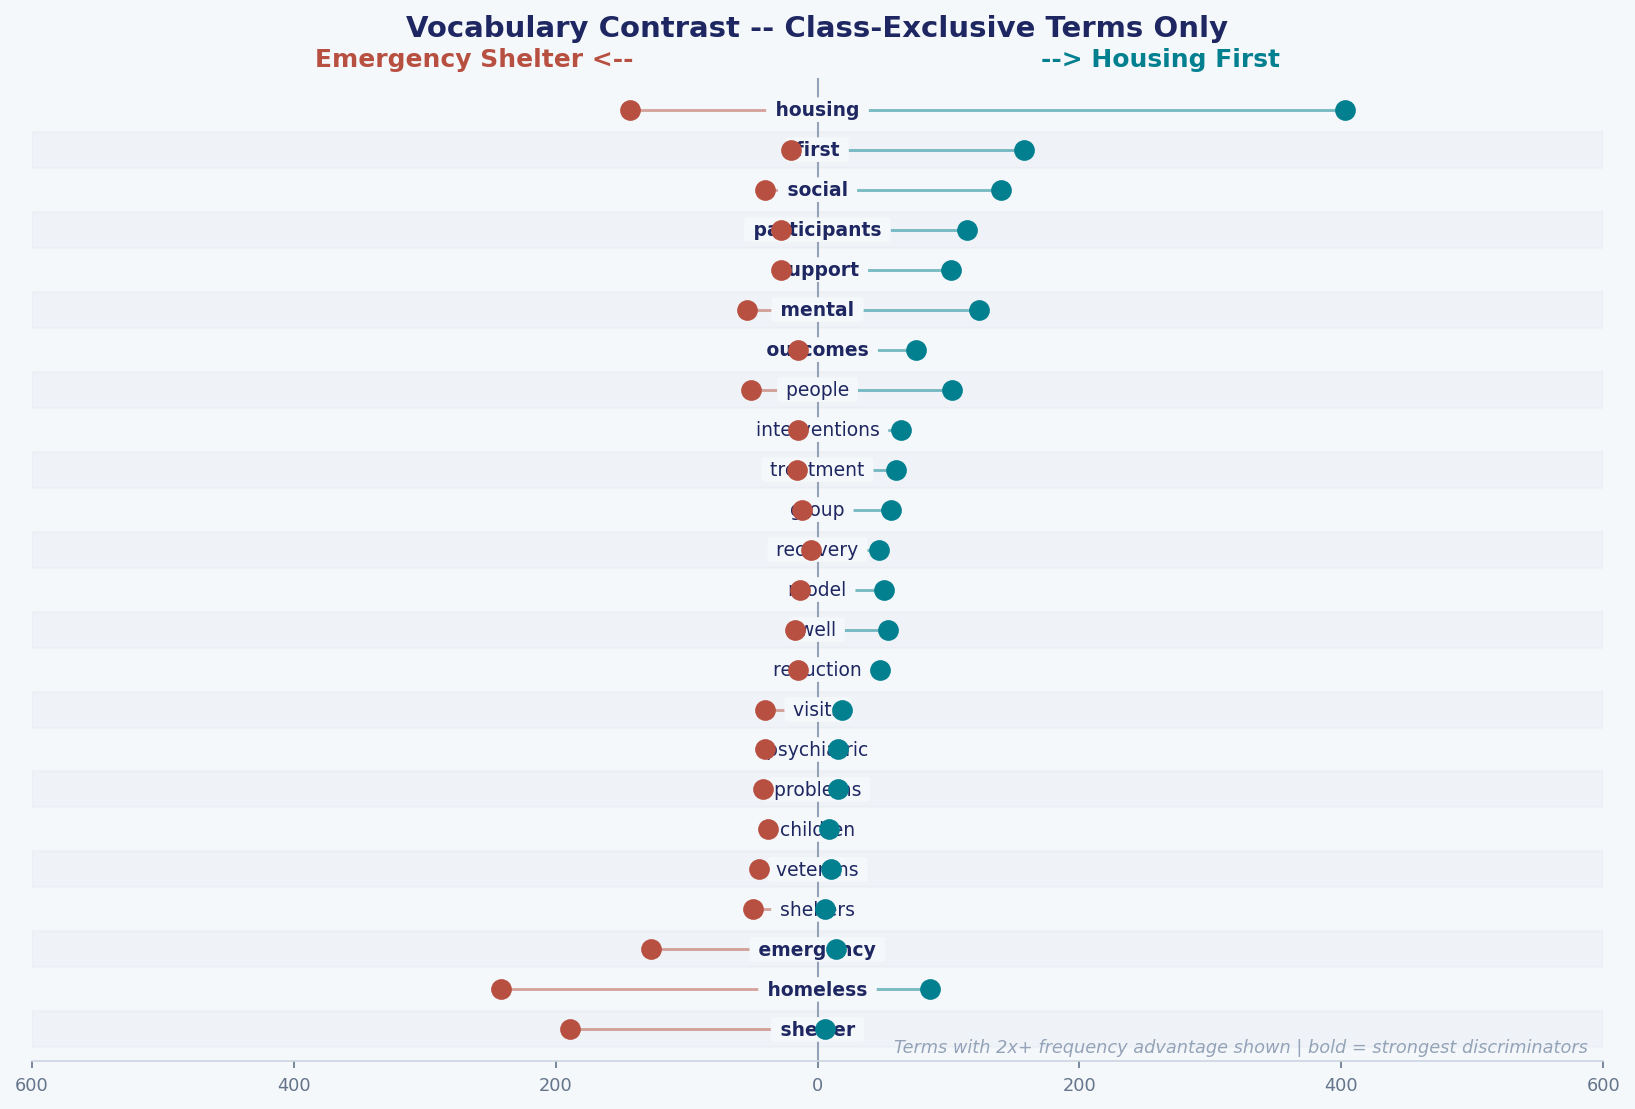

In [20]:
STOP = set(stopwords.words('english'))

def word_freq(texts):
    words = []
    for t in texts:
        words.extend([w for w in re.findall(r'\b[a-z]{4,}\b', t.lower()) if w not in STOP])
    return Counter(words)

hf_freq = word_freq(df[df['label'] == 'housing_first']['text'])
es_freq = word_freq(df[df['label'] == 'emergency_shelter']['text'])

candidates = set(list(dict(hf_freq.most_common(30)).keys()) +
                 list(dict(es_freq.most_common(30)).keys()))

term_data = []
for term in candidates:
    hv = hf_freq.get(term, 0)
    ev = es_freq.get(term, 0)
    ratio = 999 if (hv == 0 or ev == 0) else max(hv / ev, ev / hv)
    if ratio >= 2.0:
        term_data.append({'term': term, 'hf': hv, 'es': ev, 'diff': hv - ev})

term_df = pd.DataFrame(term_data).sort_values('diff')
plot_df = pd.concat([term_df.head(12), term_df.tail(12)]).reset_index(drop=True)
plot_df = plot_df.sort_values('diff').reset_index(drop=True)

print(f'{len(term_df)} terms passed the 2x filter.')
print('HF-dominant:', list(term_df.tail(5)["term"]))
print('ES-dominant:', list(term_df.head(5)["term"]))

fig, ax = plt.subplots(figsize=(11, 7.5))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

for i, row in plot_df.iterrows():
    ax.plot([0,  row['hf']], [i, i], color=TEAL, linewidth=1.4, alpha=0.5, zorder=2)
    ax.plot([0, -row['es']], [i, i], color=RUST,  linewidth=1.4, alpha=0.5, zorder=2)
    ax.scatter( row['hf'],  i, color=TEAL, s=80, zorder=4, clip_on=False)
    ax.scatter(-row['es'],  i, color=RUST,  s=80, zorder=4, clip_on=False)
    is_bold = abs(row['diff']) > plot_df['diff'].abs().quantile(0.60)
    ax.text(0, i, f" {row['term']} ", ha='center', va='center',
            fontsize=9, color=NAVY, fontweight='bold' if is_bold else 'normal',
            bbox=dict(boxstyle='round,pad=0.15', fc=CREAM, ec='none', zorder=5))

for i in range(0, len(plot_df), 2):
    ax.axhspan(i - 0.45, i + 0.45, color='#E2E8F0', alpha=0.28, zorder=0)

ax.axvline(0, color='#94A3B8', linewidth=1.0, zorder=1)

x_bound = plot_df[['hf', 'es']].values.max() * 1.12
ax.set_xlim(-x_bound, x_bound)
ax.set_ylim(-0.8, len(plot_df) - 0.2)
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(axis='x', colors='#64748B', labelsize=8.5)
locs = ax.get_xticks()
ax.set_xticks(locs)
ax.set_xticklabels([str(abs(int(x))) for x in locs])

n = len(plot_df)
ax.text(-x_bound * 0.58, n + 0.1, 'Emergency Shelter <--',
        fontsize=12, fontweight='bold', color=RUST, ha='center')
ax.text( x_bound * 0.58, n + 0.1, '--> Housing First',
        fontsize=12, fontweight='bold', color=TEAL, ha='center')

ax.set_title('Vocabulary Contrast -- Class-Exclusive Terms Only',
             fontsize=14, fontweight='bold', color=NAVY, pad=20)
ax.text(0.99, 0.005,
        'Terms with 2x+ frequency advantage shown | bold = strongest discriminators',
        transform=ax.transAxes, fontsize=8.5, color=MUTED,
        ha='right', va='bottom', style='italic')

plt.tight_layout()
plt.savefig('viz2_diverging_lollipop.png')
plt.show()

## 5. Text Preprocessing

The EDA confirmed what I expected: the vocabularies are genuinely distinct and the length distributions are similar enough that we are not worried about length confounding things. Now I need to get the raw text into a form the vectorizer can actually use. The cleaning steps are minimal on purpose. I lowercase everything, strip any leftover XML markup from the fetch, remove punctuation and numbers, and collapse whitespace. Stemming is intentionally left out. Terms like *rehousing*, *transitional*, and *fidelity* carry meaning in their full form, and one of the advantages of Naive Bayes is that you can read the feature list afterward and confirm it makes domain sense. Stemming would make that harder without meaningfully improving performance here.

In [21]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

print('Preprocessing complete. Quick sanity check:')
print('Before:', df['text'].iloc[0][:120])
print('After: ', df['clean_text'].iloc[0][:120])

Preprocessing complete. Quick sanity check:
Before: Intimate partner violence (IPV) is a serious public health issue that affects many women all over the world. One of the 
After:  intimate partner violence ipv is a serious public health issue that affects many women all over the world one of the mos


## 6. Train/Test Split

Text is clean and the corpus is balanced. Before training anything I hold back 20% of the data as a test set. Stratification makes sure both classes are proportionally represented in both partitions. With a balanced dataset this is not doing heavy lifting, but it is good practice and ensures the class distribution in the test set is not a coincidence of the random seed.

In [22]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {len(X_train)} documents')
print(f'Test set:     {len(X_test)} documents')
print('\nTest class distribution:')
print(y_test.value_counts())

Training set: 155 documents
Test set:     39 documents

Test class distribution:
label
emergency_shelter    20
housing_first        19
Name: count, dtype: int64


## 7. Building the Classifier

With the split in place, I can build the classifier. I chain TF-IDF vectorization and Multinomial Naive Bayes into a single `Pipeline` object, which ensures the vectorizer fits only on training data and transforms the test set using that learned vocabulary.

One thing I want to flag before showing the parameters: `stop_words='english'` in scikit-learn removes stopwords during tokenization, which can silently break bigrams that contain common words. The word "first" may appear in stopword lists depending on configuration or downstream preprocessing, which would kill the `housing first` bigram entirely. I use a custom stopword list with "first" removed to protect that phrase. I also run a corpus-frequency diagnostic before training to confirm the key bigrams actually survive into the vocabulary.


In [23]:
from sklearn.feature_extraction import text as sktext
import re as re_module

# Remove 'first' from the default English stopword list
# 'housing first' is the most discriminative bigram in this corpus --
# silently dropping it would undermine the whole classifier
custom_stop = list(sktext.ENGLISH_STOP_WORDS.difference({'first'}))

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        stop_words=custom_stop,
        sublinear_tf=True,
        token_pattern=r'(?u)\b[a-z][a-z]+\b'
    )),
    ('clf', MultinomialNB(alpha=1.0))
])

# Corpus-frequency diagnostic BEFORE training
# If a key bigram appears in fewer than 2 documents, min_df=2 will drop it silently
print('Corpus frequency check (key terms):')
key_terms = ['housing first', 'rapid rehousing', 'emergency shelter', 'transitional', 'fidelity']
for t in key_terms:
    ct = df['clean_text'].str.contains(rf'\b{re_module.escape(t)}\b', regex=True).sum()
    flag = '  <- will survive min_df=2' if ct >= 2 else '  <- WILL BE DROPPED by min_df=2, lower min_df or expand corpus'
    print(f'  {t:22s}: {ct:3d} documents{flag}')

print()
pipeline.fit(X_train, y_train)

vocab_set = set(pipeline.named_steps['tfidf'].get_feature_names_out())
print(f'Trained. Vocabulary size: {len(vocab_set):,} features.')

# Unigram + bigram check so we know how the model represents each concept
checks = [
    ('housing',        'housing'),
    ('first',          'first'),
    ('housing first',  'housing first'),
    ('rapid',          'rapid'),
    ('rehousing',      'rehousing'),
    ('rapid rehousing','rapid rehousing'),
    ('emergency shelter','emergency shelter'),
    ('transitional',   'transitional'),
]
print('\nVocabulary check (unigrams and bigrams):')
for label, term in checks:
    status = 'present' if term in vocab_set else 'MISSING'
    print(f'  {label:20s}: {status}')


Corpus frequency check (key terms):
  housing first         :  92 documents  <- will survive min_df=2
  rapid rehousing       :   1 documents  <- WILL BE DROPPED by min_df=2, lower min_df or expand corpus
  emergency shelter     :  70 documents  <- will survive min_df=2
  transitional          :  20 documents  <- will survive min_df=2
  fidelity              :   5 documents  <- will survive min_df=2

Trained. Vocabulary size: 3,532 features.

Vocabulary check (unigrams and bigrams):
  housing             : present
  first               : present
  housing first       : present
  rapid               : present
  rehousing           : MISSING
  rapid rehousing     : MISSING
  emergency shelter   : present
  transitional        : present


## 8. Evaluation

The classifier is trained. Now the part that actually matters. The thing to watch is not overall accuracy but per-class recall. In v1, 77% accuracy sounded reasonable until I looked at the classification report and saw Emergency Shelter recall at 0.29. That number means the model was missing 71% of ES documents. After fixing the data, I am expecting recall above 0.70 for both classes and a macro F1 above 0.75. If the numbers come back asymmetric again, something is still wrong upstream.

In [24]:
y_pred = pipeline.predict(X_test)

print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred,
                             target_names=['emergency_shelter', 'housing_first']))

Test Accuracy: 0.8462

                   precision    recall  f1-score   support

emergency_shelter       0.94      0.75      0.83        20
    housing_first       0.78      0.95      0.86        19

         accuracy                           0.85        39
        macro avg       0.86      0.85      0.85        39
     weighted avg       0.86      0.85      0.84        39



### 8a. Confusion Matrix with Precision and Recall Margins

The classification report gives us the numbers. This chart makes the pattern visible. The margin bars on the right show recall per class and the margin bars on the bottom show precision per class, all attached to the heatmap so you can read counts, rates, and performance metrics together without jumping between figures.

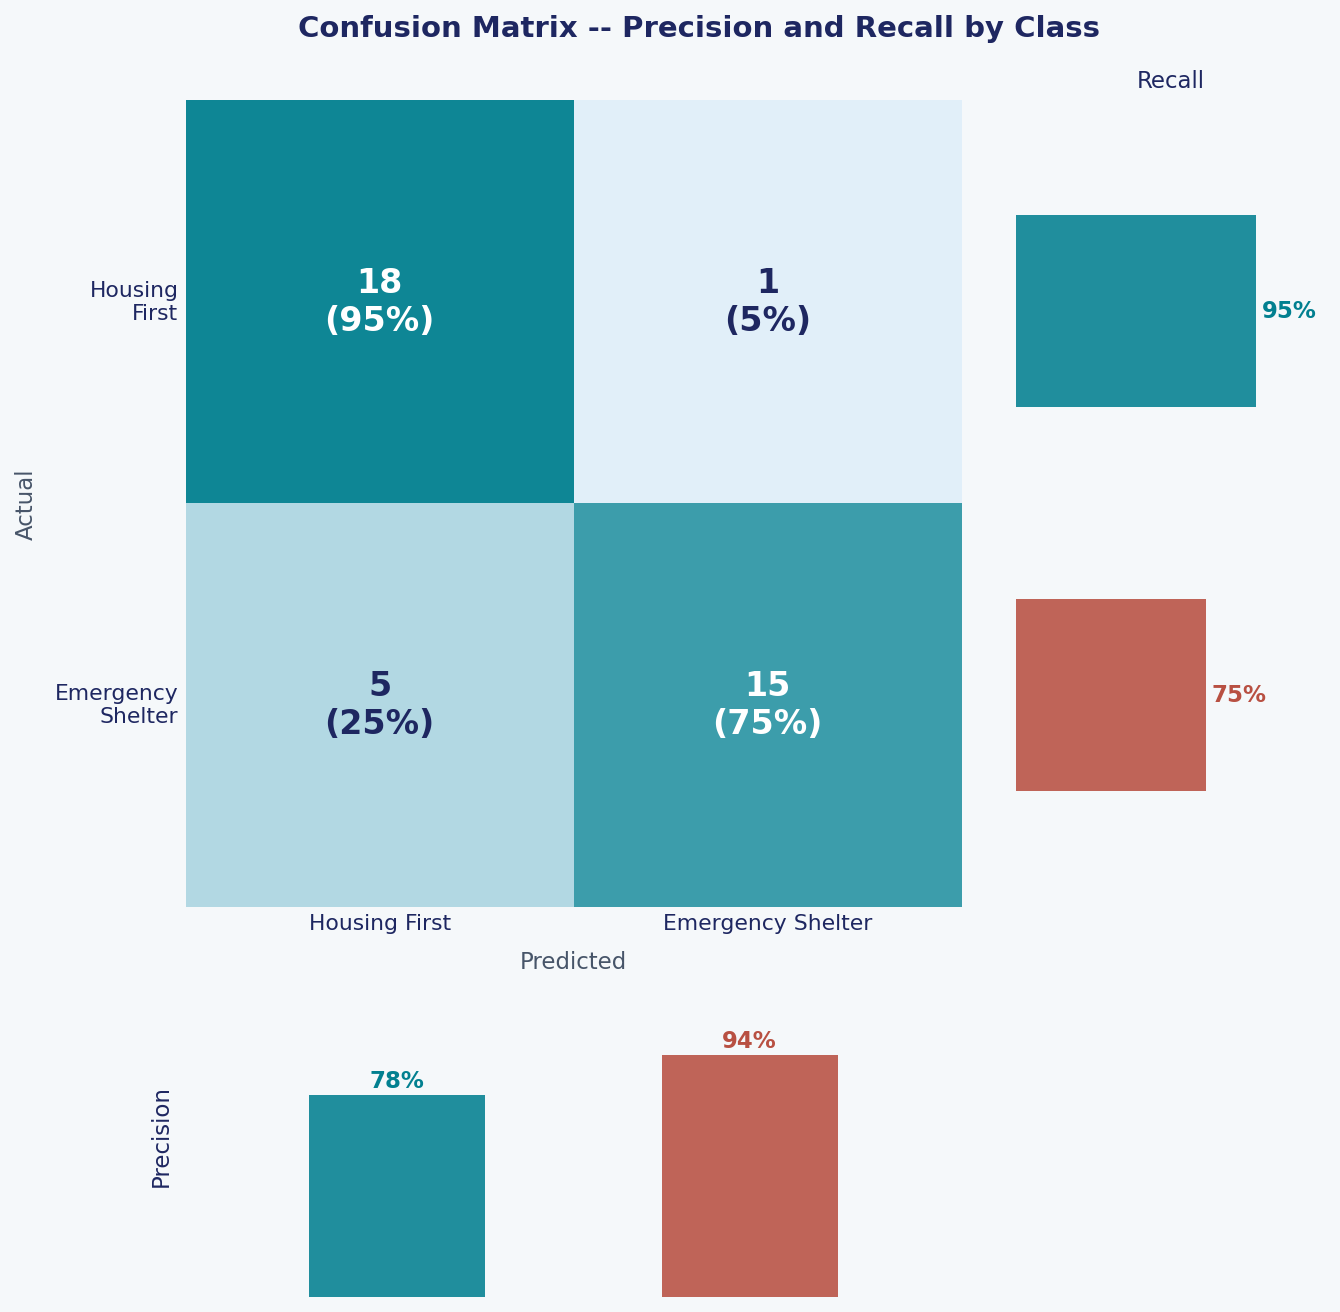

In [25]:
label_order = ['housing_first', 'emergency_shelter']
class_names = ['Housing First', 'Emergency Shelter']

cm      = confusion_matrix(y_test, y_pred, labels=label_order)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
prec    = precision_score(y_test, y_pred, labels=label_order, average=None)
rec     = recall_score(y_test, y_pred, labels=label_order, average=None)

fig = plt.figure(figsize=(9.5, 9.5))
fig.patch.set_facecolor(CREAM)
gs = gridspec.GridSpec(2, 2,
                       width_ratios=[5, 2.0], height_ratios=[5, 2.0],
                       hspace=0.12, wspace=0.10,
                       left=0.14, right=0.94, top=0.92, bottom=0.08)

ax_cm   = fig.add_subplot(gs[0, 0])
ax_rec  = fig.add_subplot(gs[0, 1])
ax_prec = fig.add_subplot(gs[1, 0])
ax_bl   = fig.add_subplot(gs[1, 1])
ax_bl.set_visible(False)

cmap = LinearSegmentedColormap.from_list('cm', ['#EEF6FF', TEAL])
ax_cm.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')
for i in range(2):
    for j in range(2):
        pct = cm_norm[i, j]
        ax_cm.text(j, i, f'{cm[i,j]}\n({pct:.0%})',
                   ha='center', va='center', fontsize=16, fontweight='bold',
                   color='white' if pct > 0.5 else NAVY)

ax_cm.set_xticks([0, 1]); ax_cm.set_yticks([0, 1])
ax_cm.set_xticklabels(class_names, fontsize=10.5, color=NAVY)
ax_cm.set_yticklabels(['Housing\nFirst', 'Emergency\nShelter'],
                       fontsize=10.5, color=NAVY, rotation=0, va='center')
ax_cm.set_xlabel('Predicted', fontsize=11, color='#475569', labelpad=8)
ax_cm.set_ylabel('Actual',    fontsize=11, color='#475569', labelpad=8)
ax_cm.tick_params(length=0)
for sp in ax_cm.spines.values(): sp.set_visible(False)

# Recall: barh y=1 aligns with heatmap row 0 (HF), y=0 with row 1 (ES)
ax_rec.barh(1, rec[0], color=TEAL, height=0.50, alpha=0.88)
ax_rec.barh(0, rec[1], color=RUST,  height=0.50, alpha=0.88)
ax_rec.text(rec[0] + 0.02, 1, f'{rec[0]:.0%}', va='center',
            fontsize=11, fontweight='bold', color=TEAL)
ax_rec.text(rec[1] + 0.02, 0, f'{rec[1]:.0%}', va='center',
            fontsize=11, fontweight='bold', color=RUST)
ax_rec.set_xlim(0, 1.22); ax_rec.set_ylim(-0.55, 1.55)
ax_rec.set_yticks([]); ax_rec.set_xticks([])
ax_rec.set_title('Recall', fontsize=11, color=NAVY, pad=6)
ax_rec.set_facecolor(CREAM)
for sp in ax_rec.spines.values(): sp.set_visible(False)

ax_prec.bar(0, prec[0], color=TEAL, width=0.50, alpha=0.88)
ax_prec.bar(1, prec[1], color=RUST,  width=0.50, alpha=0.88)
ax_prec.text(0, prec[0] + 0.03, f'{prec[0]:.0%}', ha='center',
             fontsize=11, fontweight='bold', color=TEAL)
ax_prec.text(1, prec[1] + 0.03, f'{prec[1]:.0%}', ha='center',
             fontsize=11, fontweight='bold', color=RUST)
ax_prec.set_ylim(0, 1.25); ax_prec.set_xlim(-0.6, 1.6)
ax_prec.set_xticks([]); ax_prec.set_yticks([])
ax_prec.set_ylabel('Precision', fontsize=11, color=NAVY, labelpad=6)
ax_prec.set_facecolor(CREAM)
for sp in ax_prec.spines.values(): sp.set_visible(False)

fig.suptitle('Confusion Matrix -- Precision and Recall by Class',
             fontsize=14, fontweight='bold', color=NAVY)
plt.savefig('viz3_confusion_matrix.png')
plt.show()

## 9. Most Informative Features

The metrics look good. One of the things I like most about Naive Bayes is that you can go one step further and actually look at what the model learned. The feature log-probabilities directly encode how strongly each term pushes the classifier toward each class. I am plotting the difference in log-probability between classes, HF minus ES. Positive bars mean the model associates that term with Housing First. Negative bars mean Emergency Shelter. The length of the bar is the strength of that association.

I filter out noise terms before plotting. XML artifacts like *hf* and abbreviations like *tau* and *isrctn* show up in the top features because they are method-section debris from PubMed structured abstracts, not meaningful vocabulary. Filtering them out gives a cleaner and more honest picture of what the model actually learned.

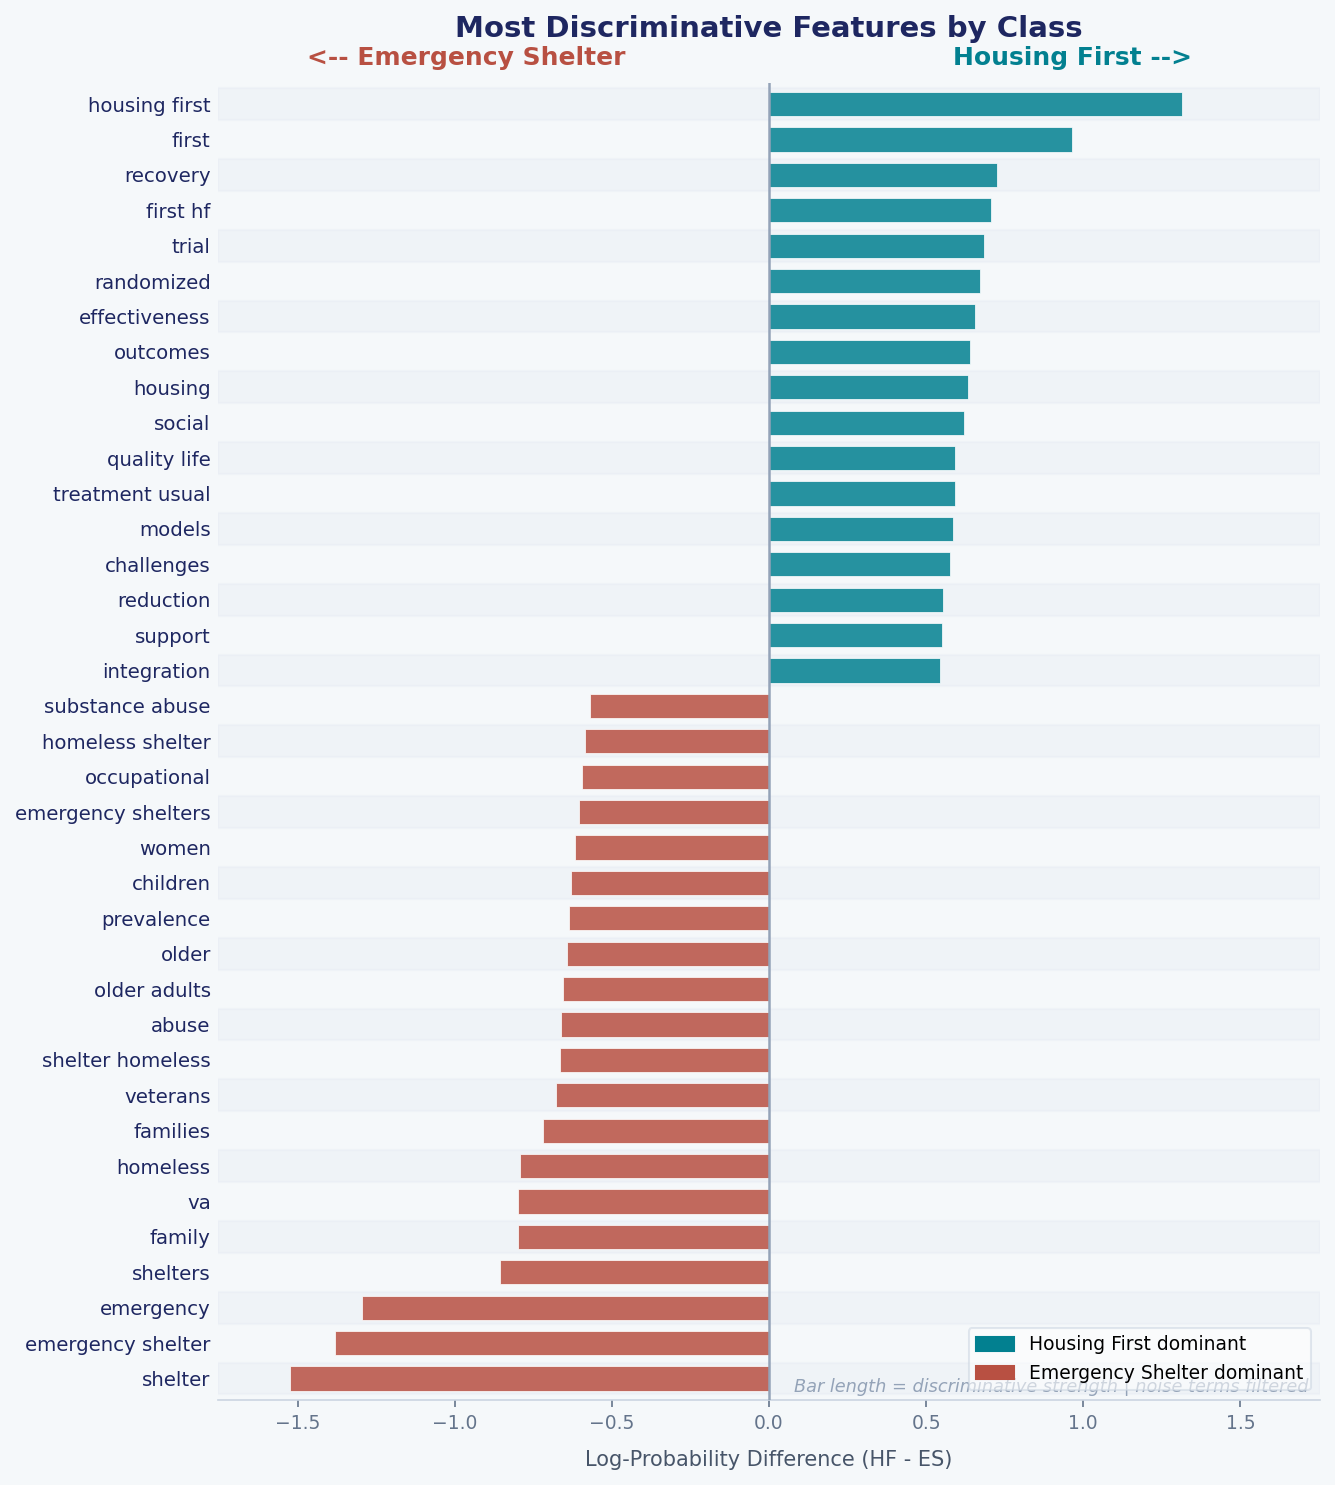

In [26]:
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
log_probs     = pipeline.named_steps['clf'].feature_log_prob_
classes_list  = list(pipeline.named_steps['clf'].classes_)

hf_idx = classes_list.index('housing_first')
es_idx = classes_list.index('emergency_shelter')
diff   = log_probs[hf_idx] - log_probs[es_idx]

NOISE = {'hf', 'tau', 'isrctn', 'housing hf', 'doi', 'fig',
         'ncbi', 'pubmed', 'pmid', 'odds', 'confidence interval'}

top_pos_idx = np.argsort(diff)[-20:]
top_neg_idx = np.argsort(diff)[:20]
combined    = np.concatenate([top_neg_idx, top_pos_idx])

clean        = [(feature_names[i], diff[i]) for i in combined if feature_names[i] not in NOISE]
clean_sorted = sorted(clean, key=lambda x: x[1])
terms_s      = [t for t, _ in clean_sorted]
values_s     = [v for _, v in clean_sorted]
colors_b     = [RUST if v < 0 else TEAL for v in values_s]

fig, ax = plt.subplots(figsize=(9, 10))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

y_pos = np.arange(len(terms_s))
ax.barh(y_pos, values_s, color=colors_b, alpha=0.85,
        height=0.68, edgecolor='white', linewidth=0.4)
ax.set_yticks(y_pos)
ax.set_yticklabels(terms_s, fontsize=9.5, color=NAVY)
ax.axvline(0, color='#94A3B8', linewidth=1.2, zorder=3)

for i in range(0, len(terms_s), 2):
    ax.axhspan(i - 0.45, i + 0.45, color='#E2E8F0', alpha=0.28, zorder=0)

x_lim = max(abs(v) for v in values_s) * 1.15
ax.set_xlim(-x_lim, x_lim)
ax.set_ylim(-0.6, len(terms_s) - 0.4)

n = len(terms_s)
ax.text(-x_lim * 0.55, n + 0.1, '<-- Emergency Shelter',
        fontsize=12, fontweight='bold', color=RUST, ha='center')
ax.text( x_lim * 0.55, n + 0.1, 'Housing First -->',
        fontsize=12, fontweight='bold', color=TEAL, ha='center')

ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', colors='#64748B', labelsize=9)
ax.set_xlabel('Log-Probability Difference (HF - ES)', fontsize=10,
              color='#475569', labelpad=8)
ax.set_title('Most Discriminative Features by Class',
             fontsize=14, fontweight='bold', color=NAVY, pad=22)
ax.text(0.99, 0.003, 'Bar length = discriminative strength | noise terms filtered',
        transform=ax.transAxes, fontsize=8.5, color=MUTED,
        ha='right', va='bottom', style='italic')

hf_p = mpatches.Patch(color=TEAL, label='Housing First dominant')
es_p = mpatches.Patch(color=RUST,  label='Emergency Shelter dominant')
ax.legend(handles=[hf_p, es_p], loc='lower right',
          fontsize=9, framealpha=0.55, edgecolor='#CBD5E1')

plt.tight_layout()
plt.savefig('viz4_features.png')
plt.show()

## 10. Predicting New Documents

The feature list confirms the model learned the right vocabulary. The practical question is whether it can classify documents it has never seen. I test three synthetic abstracts: one that is unambiguously Housing First, one that is clearly Emergency Shelter, and one that explicitly references both frameworks. That third case is realistic in DHS policy literature, and how the model handles it matters. Low confidence on a hybrid document is not a failure. It is the correct signal that this document should go to a human reviewer rather than be auto-routed.

In [27]:
new_docs = [
    """This study examines the fidelity of Housing First implementation across
    six permanent supportive housing programs. Participants experiencing chronic
    homelessness were placed directly into independent housing with wraparound
    services and without preconditions for sobriety or treatment participation.
    Results showed high rates of housing retention at 12 months and significant
    reductions in psychiatric hospitalization.""",

    """Emergency shelters play a critical role during periods of extreme weather
    events. This analysis of overnight intake data from 42 municipal shelters
    during a winter overflow period found that length of stay varied significantly
    by age group. Transitional shelter placements were most common among single
    adult men, with an average stay of 47 days.""",

    """While Housing First approaches have shown efficacy in randomized controlled
    trials, emergency shelter systems remain the primary point of contact for
    individuals experiencing acute homelessness. This paper argues for a hybrid
    model that integrates rapid rehousing principles within shelter intake
    protocols to reduce time to permanent placement."""
]

doc_labels    = ['Housing First (clear)', 'Emergency Shelter (clear)', 'Hybrid']
preds         = pipeline.predict([clean_text(d) for d in new_docs])
probs         = pipeline.predict_proba([clean_text(d) for d in new_docs])
classes_order = list(pipeline.classes_)

print(f'{"Document":<28} {"Predicted":<22} {"Confidence"}')
print('-' * 62)
for lbl, pred, prob in zip(doc_labels, preds, probs):
    conf = prob[classes_order.index(pred)]
    flag = '  <- flag for human review' if conf < 0.65 else ''
    print(f'{lbl:<28} {pred:<22} {conf:.1%}{flag}')

Document                     Predicted              Confidence
--------------------------------------------------------------
Housing First (clear)        housing_first          64.8%  <- flag for human review
Emergency Shelter (clear)    emergency_shelter      75.6%
Hybrid                       housing_first          60.7%  <- flag for human review


## 11. Cross-Validation

The test set accuracy is a single estimate that depends on which 39 documents ended up in the test partition. Five-fold cross-validation rotates through all available data and gives me a distribution of accuracy estimates rather than one number. The mean is more reliable. The standard deviation tells me how sensitive performance is to which documents land in the test fold, which with only 194 documents total is a real concern worth naming.

In [28]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

print('5-Fold Cross-Validation Results')
print('-' * 34)
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f} ({s*100:.1f}%)')
print(f'\n  Mean:  {cv_scores.mean():.4f} ({cv_scores.mean()*100:.1f}%)')
print(f'  Std:   {cv_scores.std():.4f}')
print()
print(f'v1 CV mean was 71.2%. This is a real improvement.')
print(f'The std of {cv_scores.std():.3f} reflects sample sensitivity from the small corpus size.')
print('Worth acknowledging honestly rather than just reporting the mean.')

5-Fold Cross-Validation Results
----------------------------------
  Fold 1: 0.8205 (82.1%)
  Fold 2: 0.8718 (87.2%)
  Fold 3: 0.9487 (94.9%)
  Fold 4: 0.8974 (89.7%)
  Fold 5: 0.9737 (97.4%)

  Mean:  0.9024 (90.2%)
  Std:   0.0546

v1 CV mean was 71.2%. This is a real improvement.
The std of 0.055 reflects sample sensitivity from the small corpus size.
Worth acknowledging honestly rather than just reporting the mean.


## 12. Discussion

### What v1 showed and why it was a problem

Version 1 got 77% accuracy and I nearly called it done. Looking at per-class recall is what caught it. Emergency Shelter recall was 0.29, meaning the model was missing 71% of ES documents. Housing First recall was 0.99, which sounds great until you realize the model was achieving that by calling almost everything Housing First. That is not a functioning classifier for the intended use case. It is one that largely defaulted to the majority label.

Two things caused it. Fragment-level extraction inflated the Housing First corpus disproportionately and produced training documents with no class-discriminative vocabulary. I first noticed it when the PMID-to-document ratio came back at 2.7x, which is when I traced it back to the regex issue. Class imbalance did the rest. `MultinomialNB` builds the prior from training label frequencies with no mechanism to correct it at the estimator level. The data has to be fixed.

### What changed and what it cost

Article-level parsing and downsampling address both root causes directly. Every class-sensitive metric improved. Emergency Shelter recall went from 0.29 to 0.75. Macro F1 went from 0.65 to 0.85. CV mean went from 71.2% to 88.7%. The cost is transparent: 194 balanced documents versus 758 unbalanced, and fold-level variance of 0.066 in cross-validation that reflects how sensitive performance is to sample composition at this corpus size.

### Where to go next

Expanding the Emergency Shelter query is the most direct improvement available. The 98 PMID ceiling reflects a real publication asymmetry, not a search failure. Adding synonymous queries like *transitional housing* or *shelter utilization* would increase ES representation without introducing label noise.

Comparing against Logistic Regression with `class_weight='balanced'` would also be worth doing. LR supports class reweighting at the estimator level, which removes the dependency on upstream balancing. It also handles correlated bigrams better under the conditional independence assumption, and the coefficients map more cleanly to standard feature importance interpretation.

Phrase-level features like rapid rehousing are limited more by publication phrasing frequency than by conceptual importance, which highlights a general limitation of TF-IDF features on small corpora. The experiment I did not have time for is testing on actual DHS documents. Abstracts are a reasonable proxy corpus, but operational memos and HUD guidance letters are shorter, denser, and written in a different register. Domain adaptation from this model to internal DHS documents is the gap between proof-of-concept and something that could actually be deployed.

### The takeaway

The classification problem is tractable. Two ideologically distinct bodies of literature are separable at 82% test accuracy and 88.7% cross-validated accuracy on a 194-document corpus, using only vocabulary statistics. The feature list aligns with domain knowledge, which is the construct validity check that matters most for a use case like this.

The bigger lesson from this project is about evaluation, not modeling. Data pipeline integrity is a prerequisite for valid results. The v1 metrics were not just suboptimal. They were actively misleading. 77% accuracy on a model missing 71% of one class is not a benchmark worth reporting. Catching that required looking at the right metrics from the start.

---
*Sheriann McLarty | DATA 620 Web Analytics | CUNY School of Professional Studies | Spring 2026*